# TT truncation: rank / 再構成誤差 / 保存量のtrade-off（src版）

元Notebook [`02_truncation_error_tradeoff.ipynb`](../00_fundamentals/02_truncation_error_tradeoff.ipynb) では、Notebook内で `tt_svd` / `tt_reconstruct` / `tt_num_parameters` を定義しました。

このsrc版では `nn_compression.compression` のAPIを使い、同じrank sweepを行います。

## このNotebookで何を確認するか

各bond dimensionに `max_rank` という上限を設け、**あえてrankを削って情報を捨てる**。

rank上限を小さくするとTT coreの保存量は減る一方で、再構成誤差は増える。このtrade-offを測る。

## ゴール
- `max_rank` を変えてTT-SVDする
- 実際の `bond_ranks` を記録する
- TTパラメータ数と圧縮率を求める
- relative Frobenius errorを比較する

## 1. 実験対象

$X \in \mathbb{R}^{4 \times 4 \times 4 \times 4}$ を使う。元Notebookと同じ seed `2`。

In [1]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from nn_compression.compression import (
    tt_svd,
    tt_reconstruct,
    tt_num_parameters,
)
from nn_compression.metrics import relative_frobenius_error

torch.set_default_dtype(torch.float64)
torch.manual_seed(2)

X = torch.randn(4, 4, 4, 4)
print(f"X.shape = {tuple(X.shape)}, numel = {X.numel()}")

X.shape = (4, 4, 4, 4), numel = 256


## 2. truncation付きTT-SVD

```python
cores = tt_svd(X, max_rank)
```

各段階で

$$
\widetilde r_k = \min\left(\text{max_rank},\ \text{その段階の数値rank}\right)
$$

## 3. rank sweep

`max_ranks = [1, 2, 4, 8]` を試し、次を記録する。

- `max_rank`
- `bond_ranks`
- `tt_params`
- `compression_ratio`
- `relative_error`

In [2]:
max_ranks = [1, 2, 4, 8]
results = []

for max_rank in max_ranks:
    cores = tt_svd(X, max_rank)
    X_hat = tt_reconstruct(cores)
    bond_ranks = [core.shape[2] for core in cores[:-1]]
    tt_params = tt_num_parameters(cores)
    rel_error = relative_frobenius_error(X, X_hat)
    compression_ratio = tt_params / X.numel()
    results.append({
        "max_rank": max_rank,
        "bond_ranks": bond_ranks,
        "tt_params": tt_params,
        "compression_ratio": compression_ratio,
        "relative_error": rel_error.item(),
    })

df = pd.DataFrame(results)
df

,max_rank,bond_ranks,tt_params,compression_ratio,relative_error
0,1,"[1, 1, 1]",16,0.0625,0.942147
1,2,"[2, 2, 2]",48,0.1875,0.850899
2,4,"[4, 4, 4]",160,0.6250,0.614882
3,8,"[4, 8, 4]",288,1.1250,0.294857


## 4. 可視化

1つ目は `max_rank` と `relative_error`。

2つ目は `max_rank` と `compression_ratio`。

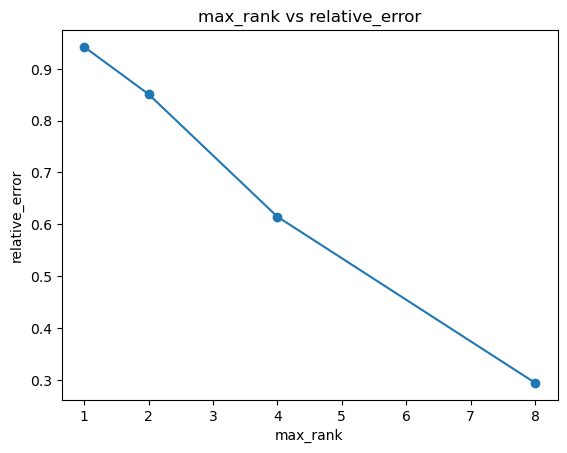

In [3]:
fig, ax = plt.subplots()
ax.plot(df["max_rank"], df["relative_error"], marker="o")
ax.set_xlabel("max_rank")
ax.set_ylabel("relative_error")
ax.set_title("max_rank vs relative_error")
plt.show()

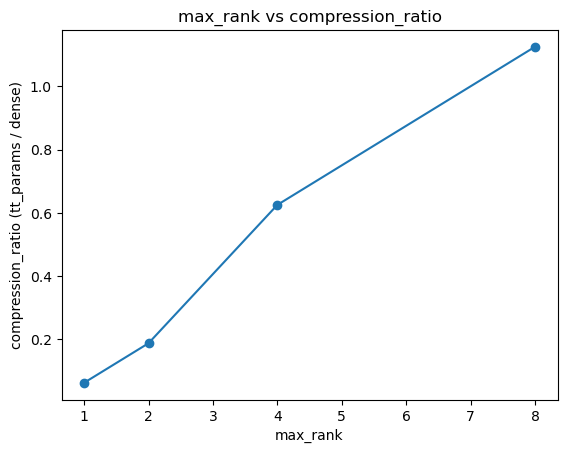

In [4]:
fig, ax = plt.subplots()
ax.plot(df["max_rank"], df["compression_ratio"], marker="o")
ax.set_xlabel("max_rank")
ax.set_ylabel("compression_ratio (tt_params / dense)")
ax.set_title("max_rank vs compression_ratio")
plt.show()

## 5. 考察

- rank上限を下げると誤差が増える
- `max_rank` と実際の `bond_ranks` が一致しない場合がある
- 小テンソルではTT coreの総要素数がdenseより多くなり得る